### Multipoint Calibration

Anisoplanatism, spatially-varying aberration across the field of view,
is not entirely compensated for by the global wavefront calibration that we demonstrated previously.
In general, setups with higher NA or setups that image into materials will
suffer from higher anisoplanatic aberration.

The wavefront calibration explored in a previous example measures the phase distortion and then
compensates for it by subtracting that phase from the phase of desired holograms. The measured phase,
however, is only valid for the $k$-vector (or steering direction, corresponding to a point on the
camera) at which the calibration was measured. Other $k$-vectors take a different path through the
optical train and thus experience different aberration. In systems with strong distortion, this
leads to good sharp correction only in the neighborhood surrounding the calibration point, such as
seen in `slmsuite` issue [#30](https://github.com/QPG-MIT/slmsuite/issues/30).

This issue is inherent to additive correction: no single additive
correction mask corrects all $k$-vectors for a given hologram. The solution is to calibrate at
many points across the field of view simultaneously, and then to "bake" the local correction into
the hologram itself using the Zernike-space holography of the previous example.

In this example, we:

- Calibrate many points across the field of view simultaneously with a version of the
  superpixel-based calibration explored before,
- Fit the correction measured at each point to Zernike polynomials,
- Interpolate these Zernike vectors across the field of view to produce a large spot array
  spanning the SLM's entire field of view, with every spot corrected for the aberration local
  to its position, and
- Refine the calibration with Zernike-based wavefront calibration, where aberration is
  iteratively subtracted from a Zernike spot array.

In [1]:
# Header. This is hidden from sphinx with the json metadata:
#   {"nbsphinx":"hidden"}

# ipython configuration (reloads source code automatically and plots inline)
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os, sys
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rc('image', cmap='inferno')

from slmsuite.hardware.cameraslms import FourierSLM
from slmsuite.holography import analysis, toolbox
from slmsuite.holography.toolbox import convert_vector

#### Initialization

We've added an aberrating element between the SLM and the camera. Light that the SLM steers
across its entire field of view (its first Nyquist zone) crosses this element along
different paths, and so picks up different aberration: anisoplanatism.

The SLM carries no blaze, so its undiffracted zeroth order sits in the middle of the field.
We keep calibration points and spots away from it.

For now, the SLM starts from its saved on-axis (superpixel) wavefront calibration. This lets us
see what a single on-axis correction misses across the field.

To start, we initialize our system:

[INF] 20:43:50 PLM Initialized PLM on display 2.
[INF] 20:43:54 FLIR Cam Initialized FLIR.
[INF] 20:43:55 FLIR Cam-PLM Initialized FourierSLM.
[INF] 20:43:55 FLIR Cam-PLM Loaded 'pixel' calibration from 'slm2_pixel_calibration_1-5V.h5'.
[INF] 20:43:55 FLIR Cam-PLM Loaded 'wavefront' calibration from 'slm2_superpixel_calibration_offset=0-25_wav=488.h5'.
[WRN] 20:43:55 FLIR Cam-PLM remove_background is enabled and a noise floor was detected; removing this background (4.2% of the average normalization).


smooth: 100%|██████████| 16/16 [00:00<00:00, 31.99it/s]


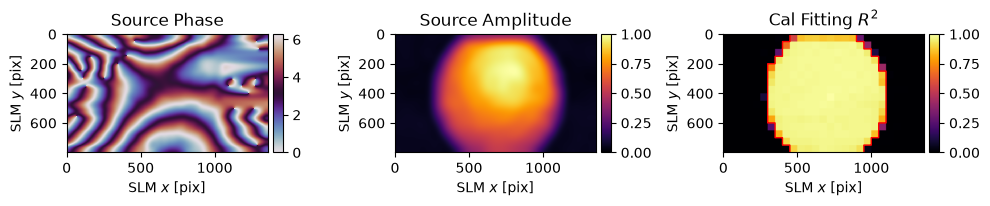

In [2]:
# Try to load physical hardware.
try:
    from slmsuite.hardware.slms.texasinstruments import PLM
    from slmsuite.hardware.cameras.flir import FLIR

    # Load the hardware.
    slm = PLM(
        'p67',
        display_number=2,
        configure_usb=True,
        usb_device_number=1,
        wav_um=0.488,
        settle_time_s=0.05,
        name='PLM',
    )

    cam = FLIR(
        serial="22562470",
        pitch_um=2.74,
        bitdepth=12,
        name="FLIR Cam"
    )
    cam.set_woi(None)

    # Load and calibrate the composite CameraSLM.
    fs = FourierSLM(cam, slm)
    fs.load_calibration('pixel', 'slm2_pixel_calibration_1-5V.h5')
    fs.pixel_calibration_process(plot=False)
    # fs.load_calibration('wavefront', 'slm2_superpixel_calibration.h5')
    fs.load_calibration('wavefront', 'slm2_superpixel_calibration_offset=0-25_wav=488.h5')
    fs.wavefront_calibration_superpixel_process(r2_threshold=.5, smooth=True, plot=True)

# Fallback to virtual hardware.
except Exception as e:
    print(f"Loading physical hardware failed; loading virtual hardware. Error:\n{str(e)}")
    from slmsuite.hardware.slms.simulated import SimulatedSLM
    from slmsuite.hardware.cameras.simulated import SimulatedCamera

    # Make the SLM and camera.
    slm = SimulatedSLM((1358, 800), pitch_um=10.8, wav_um=0.488)      # Like our PLM.
    # Program an aberration into the virtual source, as in the wavefront calibration example.
    # (The virtual camera images a single farfield, so the aberration is the same across the field
    # of view: unlike our setup, there is no anisoplanatism for the calibration to find.)
    from slmsuite.holography.toolbox.phase import zernike_sum
    slm.set_source_analytic(sim=True)
    slm.fit_aperture()                              # Scale the Zernike polynomials to the beam.
    phase_aberration = zernike_sum(
        slm,
        indices=(3, 4, 5, 7, 8),
        weights=(1, -2, 3, 1, 1),
        aperture=None,
        use_mask=False
    )
    slm.set_source_analytic(phase_offset=phase_aberration, sim=True)
    slm.set_source_analytic()                       # The calibrated source starts flat.

    # Large enough to see the SLM's entire field of view, as our camera does.
    cam = SimulatedCamera(slm, (3000, 3000), pitch_um=2.74, gain=200)

    # Tie the camera and SLM together with an analytic calibration.
    fs = FourierSLM(cam, slm)
    M, b = fs.fourier_calibration_build(
        f_eff=150e3 / slm.wav_um,                  # f_eff of 150 mm normalized to wavelength.
        theta=5 * np.pi / 180,
    )
    cam.set_affine(M, b)
    fs.fourier_calibrate_analytic(M, b)

#### Fourier Calibration

First, we project the grid used for Fourier calibration onto the full sensor. The undiffracted
zeroth order is far brighter than any spot, so we locate it with a flat phase (which sends all
of the light there) and autoexpose on the brightest pixel *away* from it. A logarithmic scale
then shows the spots blurring and distorting away from the center of the field.

[INF] 20:43:56 Fourier Grid Initialized SpotHologram.


Fourier Grid: 100%|██████████| 10/10 [00:00<00:00, 208.00it/s]


[INF] 20:43:58 FLIR Cam Autoexpose: 3.59e-03 s - 2064/4095


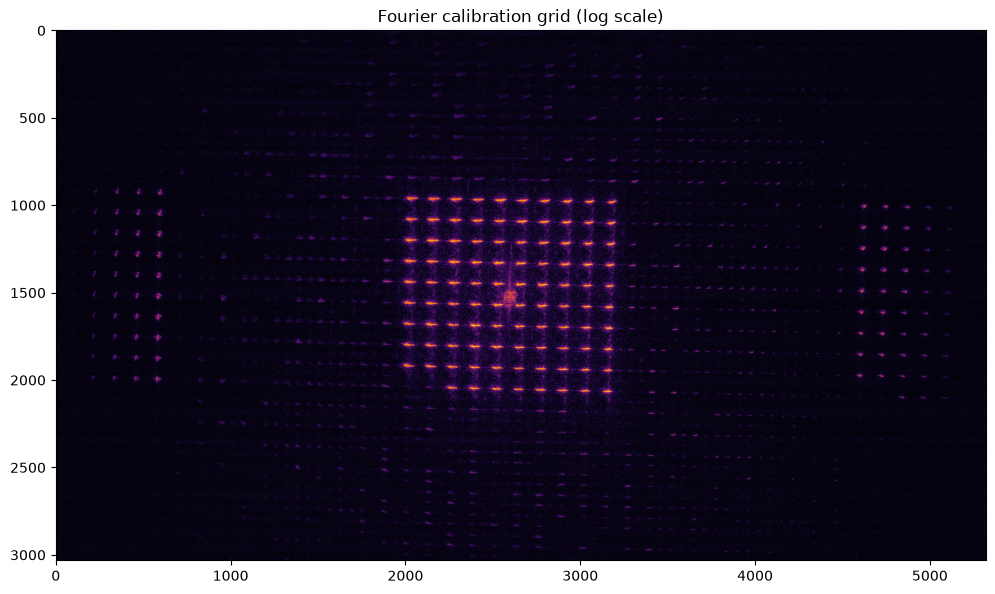

In [3]:
from matplotlib.colors import LogNorm

fs.fourier_grid_project(10, 100)
cam.autoexpose(set_fraction=0.5)

plt.figure(figsize=(12, 8))
plt.imshow(cam.get_image() + 1, norm=LogNorm())
plt.title("Fourier calibration grid (log scale)")
plt.show()

Thus, we start out by removing the lowest order aberration term: the focusing term $Z_4$.
We use the built-in `cam.autofocus()` method which accepts general function handles to `set_z` the 
position of a stage or otherwise. `cam.autofocus()` also accepts an SLM as `set_z`, where the unit
of the $z$ coordinate is in Zernike units: radians times $Z_4$.

The exposure stays fixed during the sweep, and the spots brighten as they come into focus,
so we first autoexpose the defocused grid well below saturation to leave headroom.

[INF] 20:44:00 FLIR Cam Autoexpose: 3.59e-03 s - 1955/4095
[WRN] 20:44:00 FLIR Cam Attempted to set exposure to 0.0007186 seconds, but realized 0.00071 seconds.


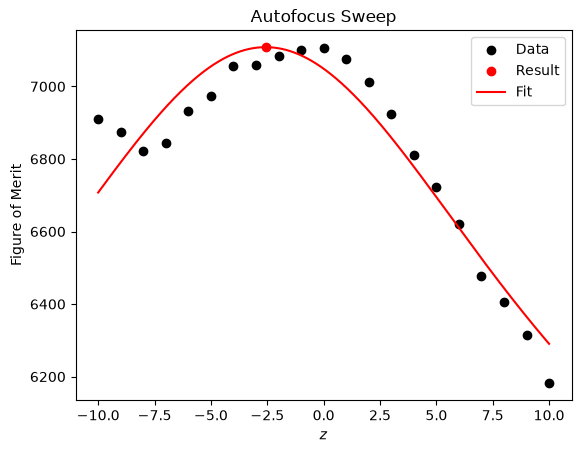

np.float64(-2.5729876063822297)

In [4]:
cam.autoexpose(set_fraction=0.1)

cam.autofocus(
    set_z=slm,
    plot=True,
    range_z=np.linspace(-10, 10, 21, endpoint=True)
)

With `cam.autofocus()` to help us, we are able to get tight enough spots to lock onto the array.

[INF] 20:44:21 Fourier Grid #2 Initialized SpotHologram.


Fourier Grid: 100%|██████████| 10/10 [00:00<00:00, 9979.31it/s]


[INF] 20:44:22 FLIR Cam Autoexpose: 3.10e-03 s - 1949/4095


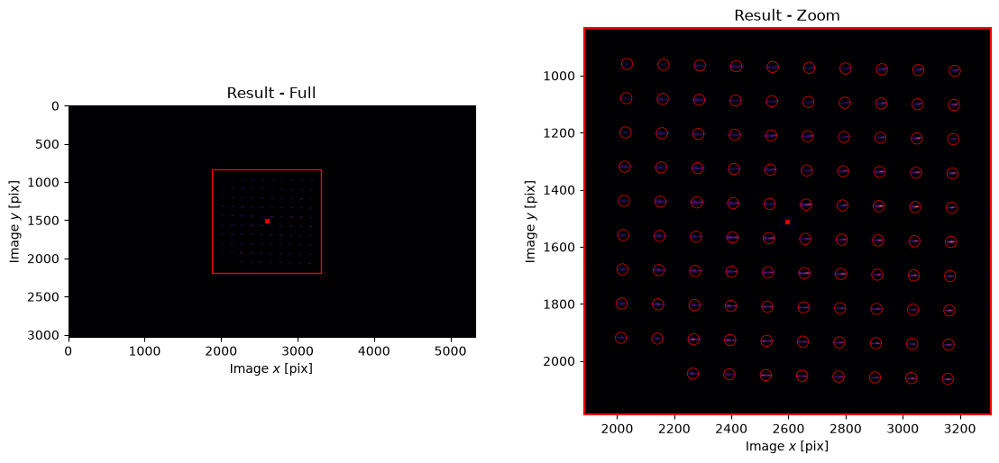

In [5]:
fs.fourier_calibrate(10, 100, autoexpose=True, plot=True);

#### The Full Field of View

With the Fourier calibration, `fs.get_farfield_extent()` gives the corners of the region
that the SLM can steer to (its first Nyquist zone), in camera pixels. We window the camera onto
this region, padded by 5% so that spots at the very edge keep room for their windows, so that
the rest of the notebook works across the SLM's entire field of view. The Fourier calibration is stored in raw sensor coordinates, so it
remains valid through the change of window.

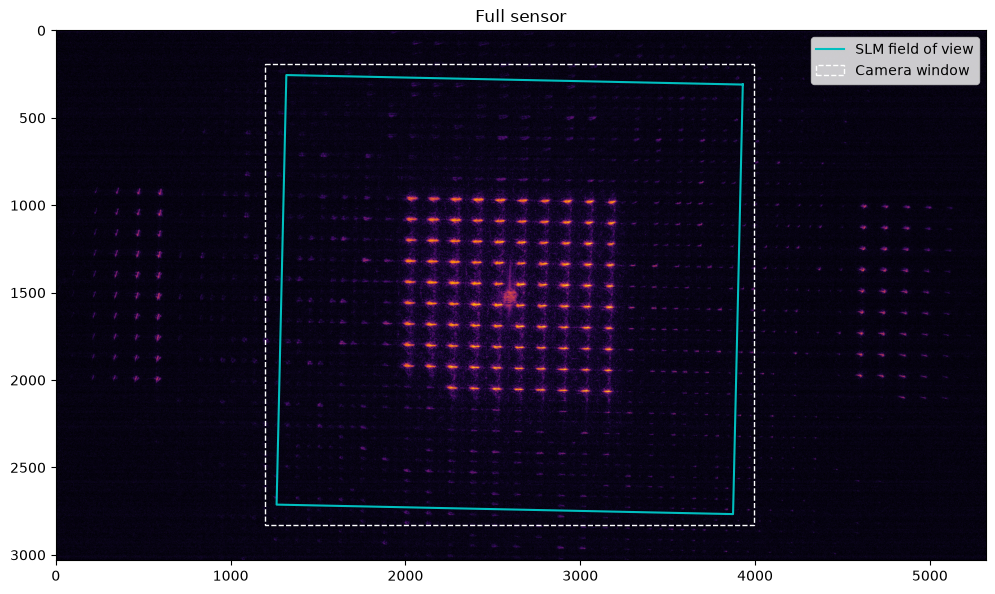

[WRN] 20:44:28 FLIR Cam Attempted to set WOI to (1196, 2800, 192, 2637), but realized (1196, 2800, 192, 2632).
camera window     : (2632, 2800)
zeroth order at   : [1400.41769289 1318.96637841]
spot size [pix]   : [2.04851124 2.04851124]


In [6]:
# The corners of the SLM's field of view on the full sensor, and an image to place them on.
cam.set_woi(None)
cam.flush()
image = cam.get_image()
corners_ij = fs.get_farfield_extent()

# Window onto their bounding box, padded by 5% (2.5% on each side).
pad = 0.025 * np.ptp(corners_ij, axis=1)
low = np.maximum(np.min(corners_ij, axis=1) - pad, 0).astype(int)
high = np.minimum(np.max(corners_ij, axis=1) + pad, cam.shape[::-1]).astype(int)

plt.figure(figsize=(12, 8))
plt.imshow(image + 1, norm=LogNorm())
plt.plot(*corners_ij, "c-", label="SLM field of view")
plt.gca().add_patch(plt.Rectangle(low, *(high - low), ec="w", fc="none", ls="--", label="Camera window"))
plt.legend(loc="upper right")
plt.title("Full sensor")
plt.show()

cam.set_woi((low[0], high[0] - low[0], low[1], high[1] - low[1]))

print("camera window     :", cam.shape)
print("zeroth order at   :", fs.zeroth_order_ij.ravel())
print("spot size [pix]   :", fs.get_farfield_spot_size(basis="ij"))

We'll lay out square arrays of spots across this field several times, so we make a helper.
`field_grid_ij()` spans a fraction `fill` of the largest box inside the field of view with an
`n` by `n` grid, and flags the spots which are clear of the undiffracted zeroth order.

To inspect every spot of a large array at once, `analysis.take()` crops a window about each
spot, and `analysis.take_plot()` tiles the windows into a single plot (`analysis.take_tile()`
returns the tiled image instead). We blank the windows of the flagged spots, so that the tiles
keep the layout of the grid.

In [7]:
def field_grid_ij(n, fill=0.9, exclusion=100):
    """An n x n grid spanning ``fill`` of the field of view, and a mask of the spots clear of the zeroth order."""
    box_ij = fs.get_farfield_extent(inscribe=True)
    center = np.mean(box_ij[:, :4], axis=1)
    half = fill * np.ptp(box_ij, axis=1) / 2

    grid_ij = np.vstack([g.ravel() for g in np.meshgrid(
        np.linspace(center[0] - half[0], center[0] + half[0], n),
        np.linspace(center[1] - half[1], center[1] + half[1], n),
    )])
    clear = np.linalg.norm(grid_ij - fs.zeroth_order_ij, axis=0) > exclusion

    return grid_ij, clear

To see the anisoplanatism, we project a spot array across the whole field with the on-axis
calibration applied. The spots carry only the tilts which steer them into place, so anything
else in their shape is aberration that the on-axis correction does not capture.

[INF] 20:44:28 CompressedSpotHologram Initialized CompressedSpotHologram.
[INF] 20:44:29 FLIR Cam Autoexpose: 9.38e-03 s - 2178/4095


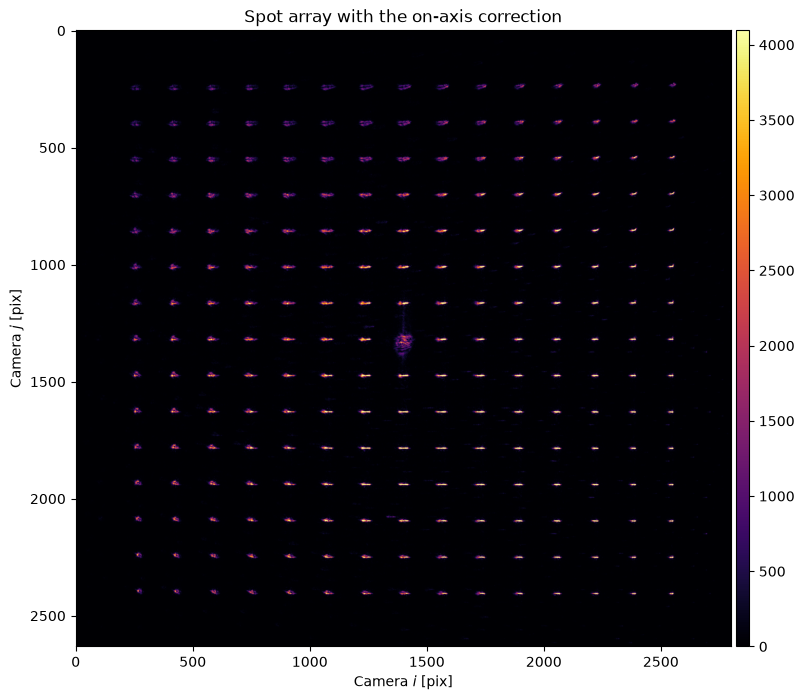

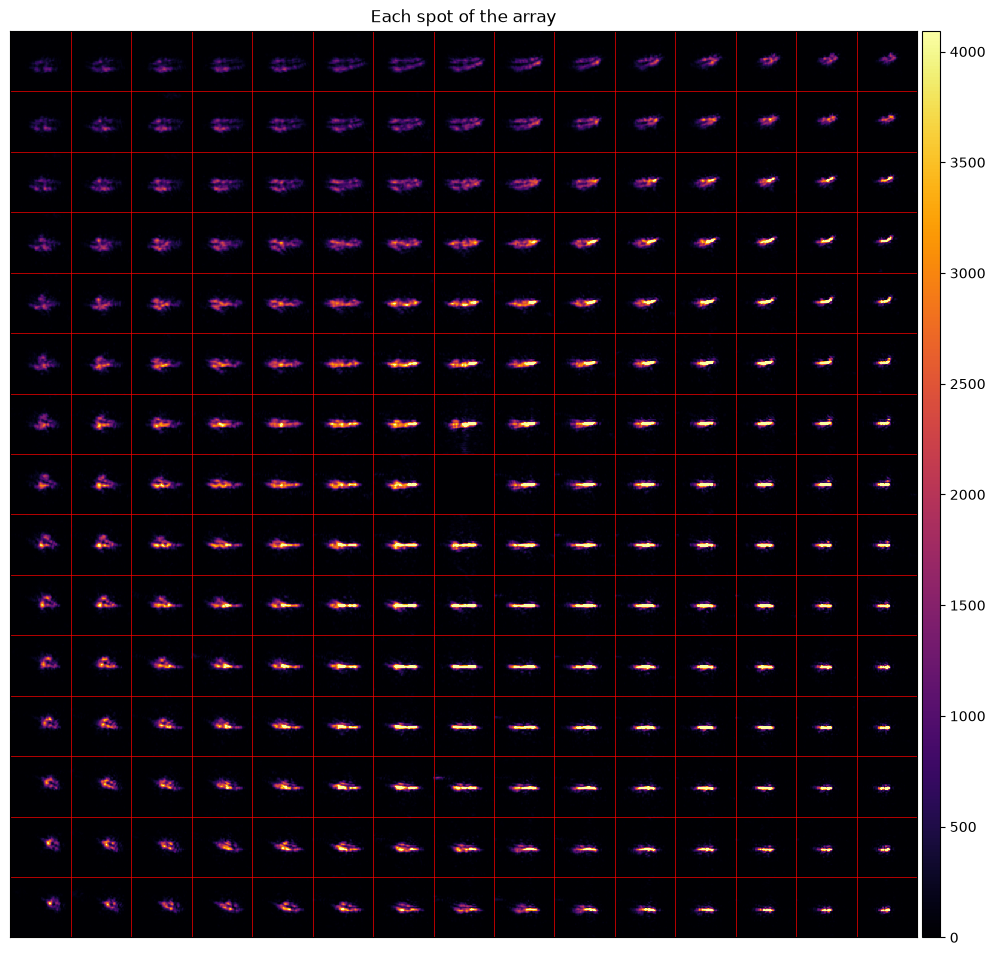

In [8]:
from slmsuite.holography.algorithms import CompressedSpotHologram

preview_ij, preview_clear = field_grid_ij(15)

preview = CompressedSpotHologram(
    spot_vectors=preview_ij[:, preview_clear],
    basis="ij",                 
    cameraslm=fs,
    cuda=True
)
preview.optimize("WGS-Kim", maxiter=20, verbose=False)

# Display with the current on-axis correction
slm.set_phase(preview.get_phase(), settle=True)
cam.autoexpose(set_fraction=4)
image = cam.get_image()

cam.plot(image, title="Spot array with the on-axis correction")
plt.show()

# A window about every spot, blanking those left out near the zeroth order.
windows = analysis.take(image, preview_ij, 100)
windows[~preview_clear] = 0

plt.figure()
plt.title("Each spot of the array")
analysis.take_plot(windows, figsize=12)

#### Multipoint Calibration Grid

When calibrating at many points, we must be considerate of effects which are not present in
single-point calibration. Specifically, each calibration point has a -1th order mirror in addition
to the target 1st order location. These -1th orders act as noise for the other points. However,
careful choice of how the grid of calibration points is aligned can lead to these mirror images
avoiding sensitive regions. This is handled automatically by `.wavefront_calibration_points()`.
In the below plot, the red spots are mirror images of the blue spots, with the intensity corresponding
to the spot index.

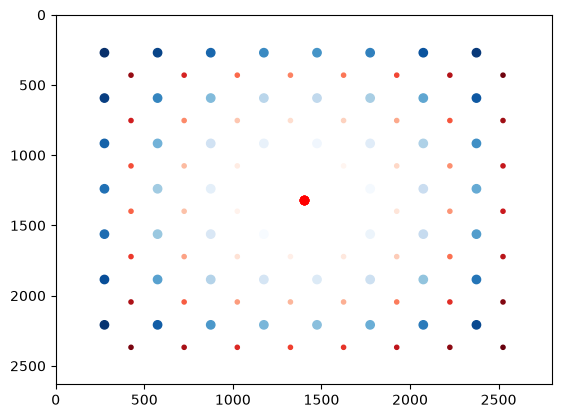

In [9]:
points_ij = fs.wavefront_calibration_points(pitch=300, avoid_mirrors=True, plot=True);

#### Multipoint Superpixel Wavefront Calibration

To start, we explore an extension to superpixel-based calibration where we calibrate
many points simultaneously. Using the `calibration_points=None`, the field of view is
densely packed with interference regions which are of appropriate size and of sufficient
separation for the given `superpixel_size`.

Superpixel calibration captures every frame at the camera's current exposure, so we set it
beforehand, as in the wavefront calibration example. The brightest frame the calibration
will see is a pair of neighboring superpixels near the center of the SLM, where the source is
brightest, interfering constructively at their calibration point. Every calibration point has
its own pair, so the brightest frame for the whole grid is the same as for a single point.
We display a stand-in for that frame, blazed to the calibration point nearest the center of
the camera, then autoexpose on that point's interference window.

The rest of the SLM (the field) is left unblazed by default, so it lands on the undiffracted
zeroth order, which `.wavefront_calibration_points()` already keeps the calibration points away from.

In [10]:
from slmsuite.holography.toolbox.phase import blaze

superpixel_size = 75

# Stand-in for the brightest calibration frame: two superpixels at the center of the SLM,
# blazed to the calibration point nearest the zeroth order.
point = points_ij[:, [np.argmin(np.linalg.norm(points_ij - fs.zeroth_order_ij, axis=0))]]
phase = slm.xp.zeros(slm.shape)
toolbox.imprint(
    phase,
    window=[slm.shape[1] // 2, 2 * superpixel_size, slm.shape[0] // 2, superpixel_size],
    function=blaze,
    grid=slm,
    vector=fs.ijcam_to_kxyslm(point),
    centered=True
)
slm.set_phase(phase, settle=True)

# Autoexpose within that point's interference window.
w, h = fs.wavefront_calibration_superpixel_window(superpixel_size).ravel()
calibration_exposure_s = cam.autoexpose(
    set_fraction=0.8,
    window=[int(point[0, 0]) - w // 2, w, int(point[1, 0]) - h // 2, h]
)

[INF] 20:44:32 FLIR Cam Autoexpose: 8.05e-03 s - 2044/4095


With the exposure set, we can run the test:

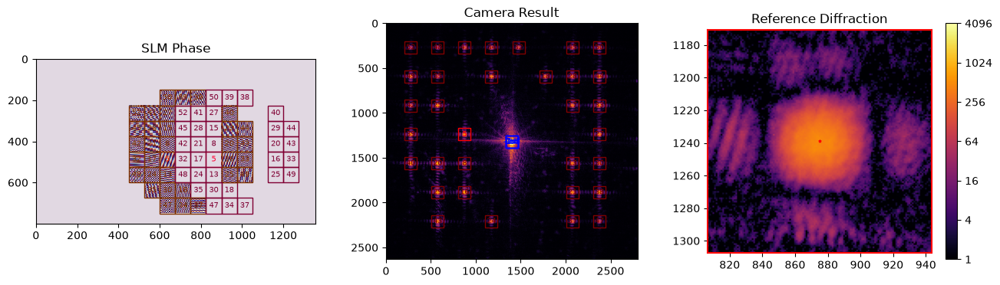

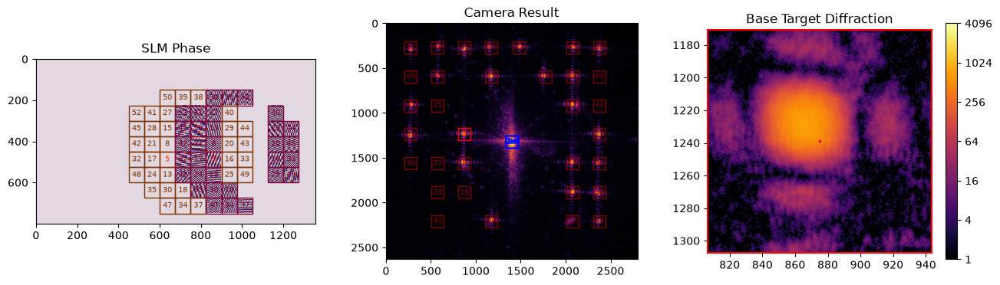

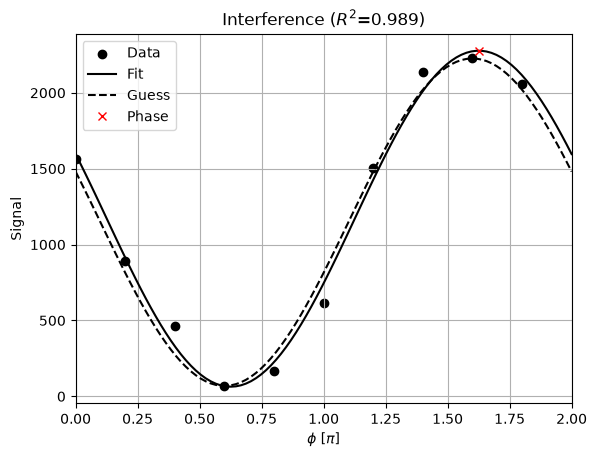

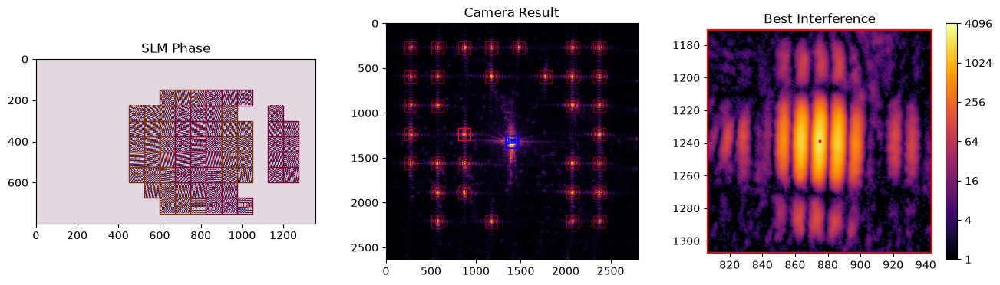

In [11]:
movie = fs.wavefront_calibrate_superpixel(
    calibration_points=points_ij,
    superpixel_size=superpixel_size,
    test_index=2,                       # Testing mode
    phase_steps=10,
    plot=3                              # Special mode to generate a phase .gif
)

from slmsuite.holography.analysis.files import save_image

save_image("wavefront-simutaneous.gif", movie, loop=0)

We use markdown to display the .gif we just made:

![Phase Movie](wavefront-simutaneous.gif)

To summarize what is happening: we're doing many interference measurements at once. For each
interference measurement, there is a superpixel pair, one of which has a shifting phase (as seen in the .gif).

Some of the calibration points are not measured during this frame because there is a conflict with
another pair. There's a complex scheduling algorithm running in the background to make sure all pairs
of reference and target superpixels are measured despite these conflicts.

Next, we perform the full calibration:

In [12]:
cam.set_exposure(calibration_exposure_s)

fs.wavefront_calibrate_superpixel(
    calibration_points=points_ij,
    superpixel_size=superpixel_size,
    phase_steps=6,
);

C:\Users\holodyne\Documents\GitHub\slmsuite\slmsuite\hardware\cameraslms\_wavefront_superpixel.py:602: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = optimize.curve_fit(cos, phases, intensities, p0=guess)
C:\Users\holodyne\Documents\GitHub\slmsuite\slmsuite\hardware\cameraslms\_wavefront_superpixel.py:610: RuntimeWarning: invalid value encountered in scalar divide
  contrast = popt[1] / (popt[1] + popt[2])
C:\Users\holodyne\Documents\GitHub\slmsuite\slmsuite\hardware\cameraslms\_wavefront_superpixel.py:615: RuntimeWarning: invalid value encountered in scalar divide
  r2 = 1 - (ss_res / ss_tot)
                                                                C:\Users\holodyne\Documents\GitHub\slmsuite\slmsuite\holography\analysis\__init__.py:1140: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(function, grid_ravel_, img, ftol=1e-5, p0=p0,)
calibration: 100%|██████████| 275/275 [16:15<00:00,  3.55s/it]  


The slightly longer runtime compared with single point calibration 
is due to scheduling around conflicting superpixel positions,
alongside overhead of fitting many results every iteration.

In [13]:
fs.save_calibration("wavefront_superpixel")

[INF] 21:01:05 FLIR Cam-PLM Saved 'wavefront_superpixel' calibration to 'c:\Users\holodyne\Documents\GitHub\slmsuite-examples\examples\FLIR Cam-PLM-wavefront_superpixel-calibration_00008.h5'.


'c:\\Users\\holodyne\\Documents\\GitHub\\slmsuite-examples\\examples\\FLIR Cam-PLM-wavefront_superpixel-calibration_00008.h5'

Now let's take a look at the results of the calibrations at the corners of the field of view.

[INF] 21:01:05 SpotHologram Initialized SpotHologram.


  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 16.66it/s]


[WRN] 21:01:06 FLIR Cam-PLM remove_background is enabled and a noise floor was detected; removing this background (4.4% of the average normalization).


smooth: 100%|██████████| 16/16 [00:00<00:00, 25.30it/s]


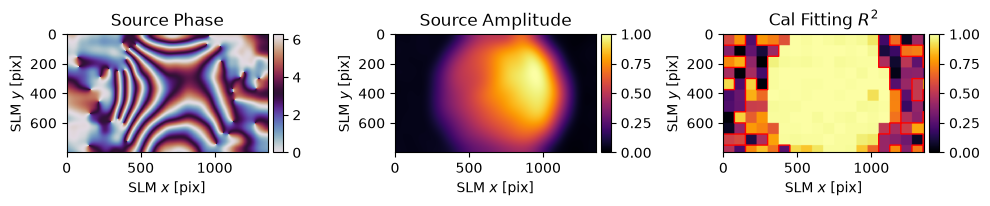

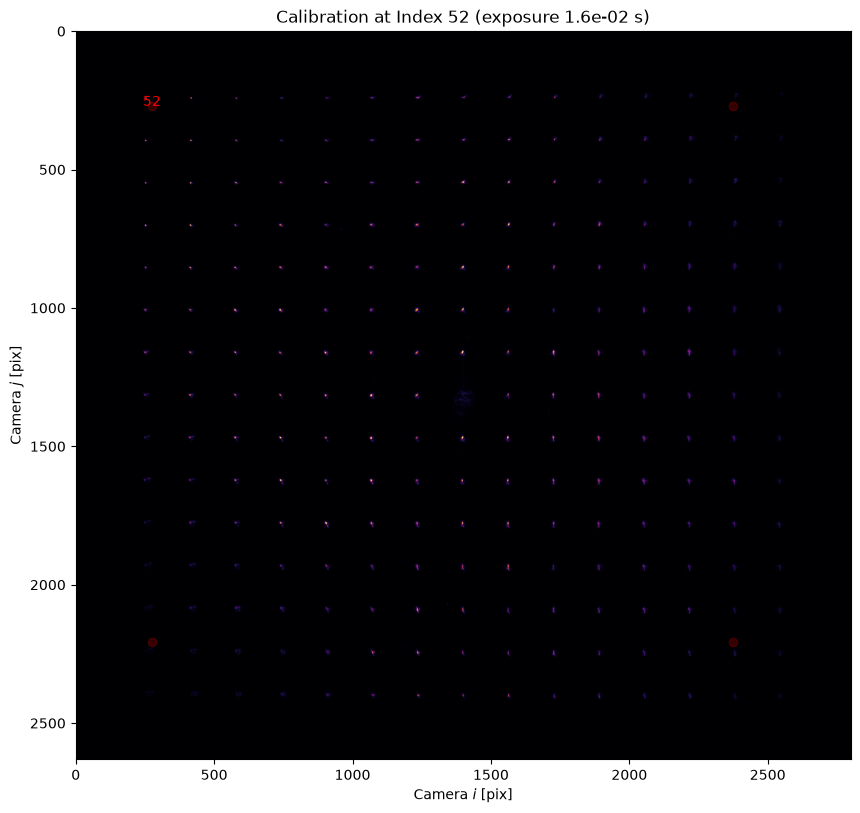

[WRN] 21:01:09 FLIR Cam-PLM remove_background is enabled and a noise floor was detected; removing this background (0.9% of the average normalization).


smooth: 100%|██████████| 16/16 [00:00<00:00, 26.06it/s]


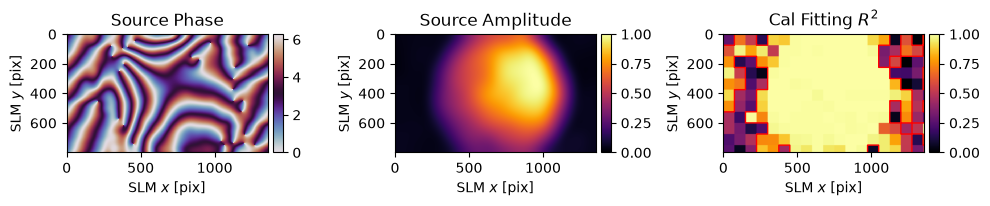

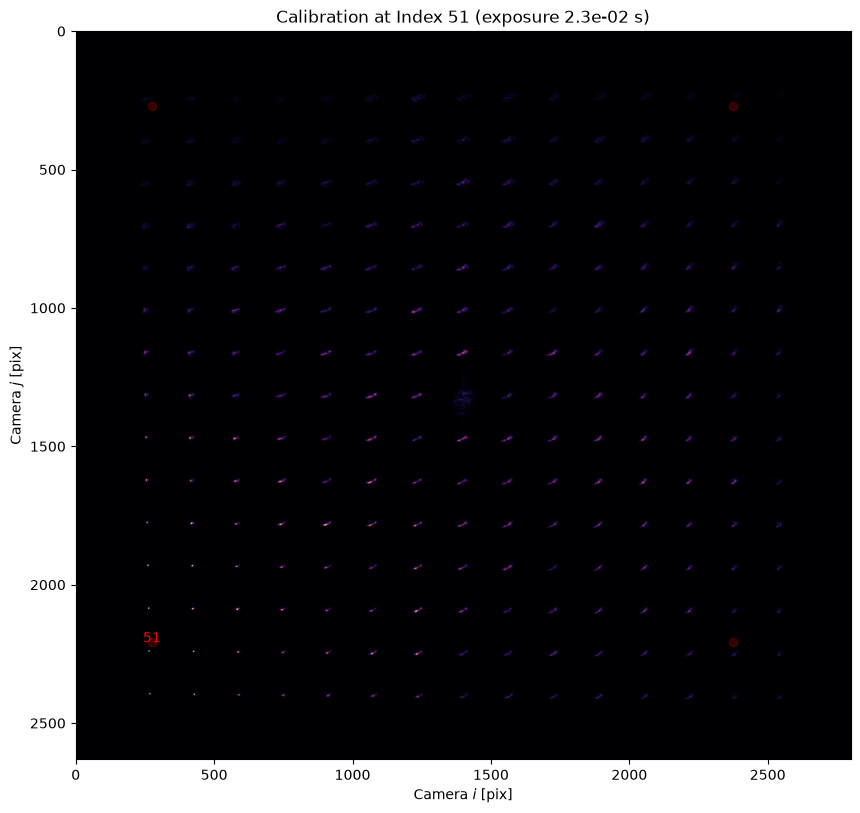

[WRN] 21:01:12 FLIR Cam-PLM remove_background is enabled and a noise floor was detected; removing this background (1.5% of the average normalization).


smooth: 100%|██████████| 16/16 [00:00<00:00, 26.46it/s]


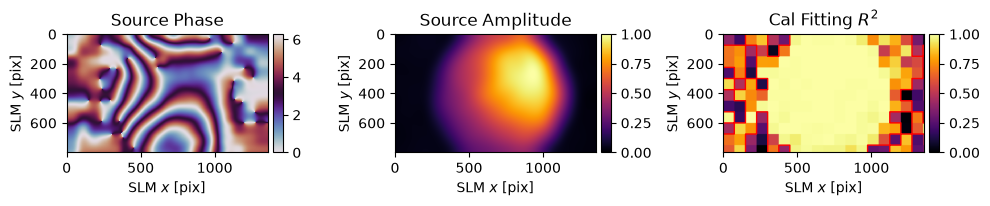

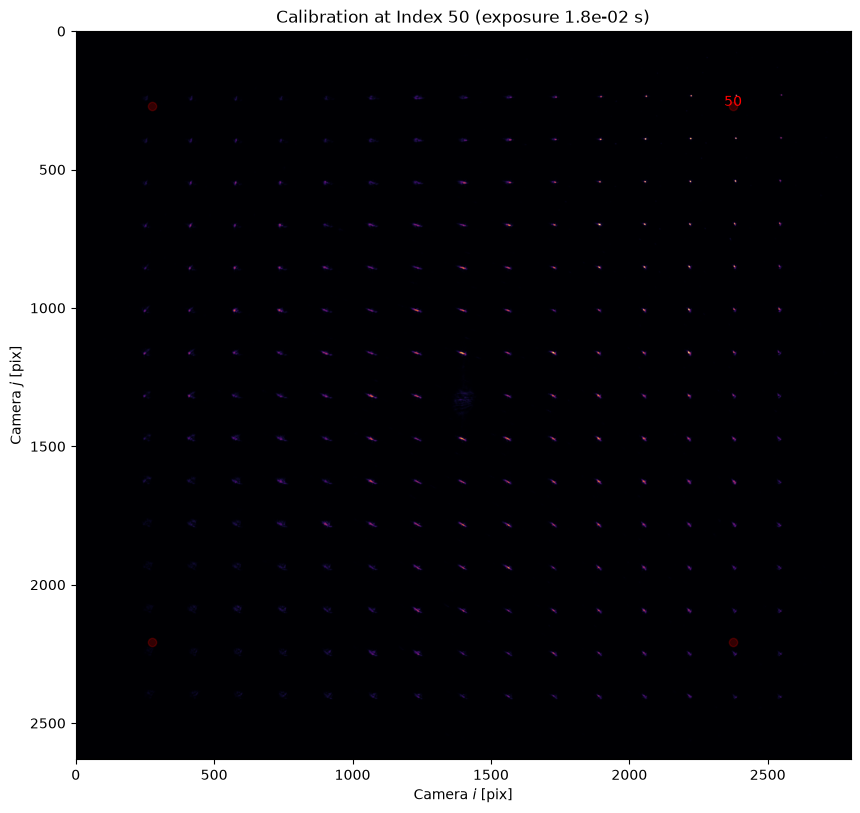

[WRN] 21:01:15 FLIR Cam-PLM remove_background is enabled and a noise floor was detected; removing this background (3.3% of the average normalization).


smooth: 100%|██████████| 16/16 [00:00<00:00, 26.30it/s]


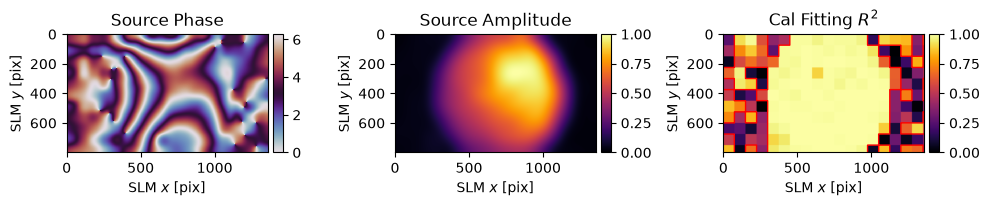

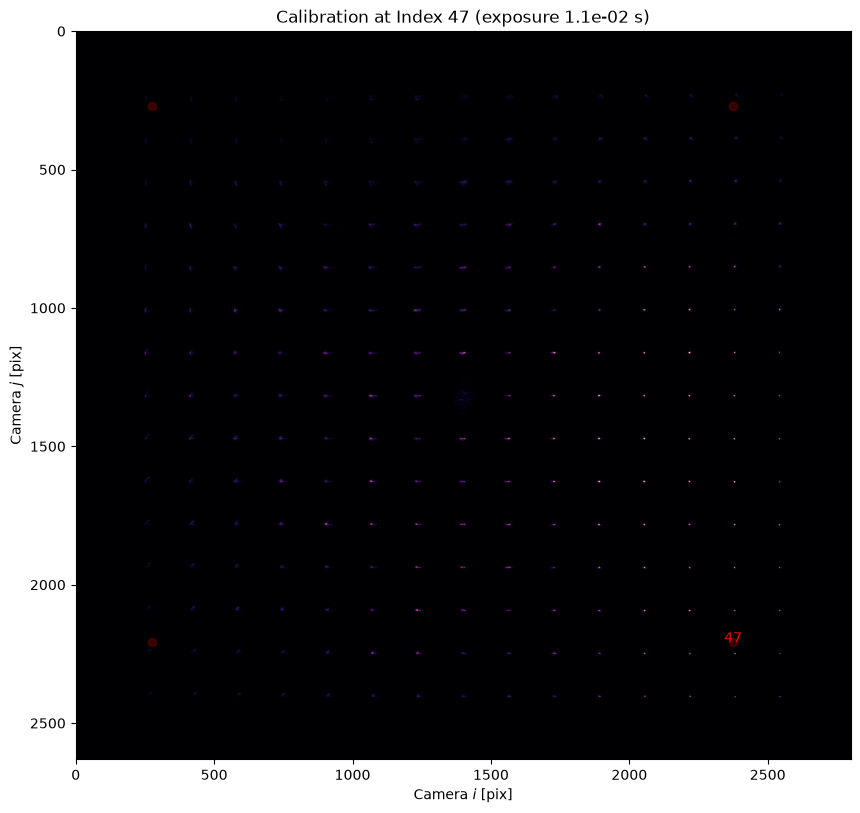

In [14]:
# Make a grid of spots across the field of view.
square, square_clear = field_grid_ij(15)

from slmsuite.holography.algorithms import SpotHologram
hologram = SpotHologram(shape=(2048, 2048), spot_vectors=square[:, square_clear], basis='ij', cameraslm=fs)
hologram.optimize(maxiter=10,
                  feedback="experimental_spot")

# Find the four corner indices to plot.
points = fs.calibrations["wavefront_superpixel"]["calibration_points"]
corner_indices = []
for x in [-1, 1]:
    for y in [-1, 1]:
        max_corner = x * points[0] + y * points[1]
        corner_indices.append(np.argmax(max_corner))

# For each corner index, plot the correction wavefront and the resulting hologram aberration.
for i in corner_indices:
    dat = fs.wavefront_calibration_superpixel_process(index=i, r2_threshold=.5, smooth=True, plot=True);
    
    slm.set_phase(hologram, settle=True)
    # Overexpose to better visualize the hologram aberration.
    exposure_s = cam.autoexpose(set_fraction=2, verbose=False)

    fig,ax = plt.subplots(1,1,figsize=(10,10))
    cam.plot(title=f"Calibration at Index {i} (exposure {exposure_s:.1e} s)", ax=ax)
    ax.scatter(*points[:, corner_indices], marker="o", color="r", alpha=.2)
    ax.annotate(f"{i}", (points[0, i], points[1, i]), ha='center', color="r")
    plt.show()

While the wavefront correction phase might look similar for each corner point,
the resulting spot array only shows tightly focused spots in a patch around the point of correction.
Only one of these corrections can be loaded into `slm.source` at a time. To correct every
spot at once, we will instead bake the correction local to each spot into the hologram itself.

#### Fitting the Calibration to Zernike Polynomials

Zernike-space holography, from the previous example, lets every spot of a hologram carry its
own Zernike vector. So we fit the correction phase measured at every calibration point to
Zernike polynomials.

Zernike polynomials are defined on the unit disk, so we first fit `slm.aperture` to the
source amplitude that the calibration measured. This places the polynomials on the beam itself.
The aperture must stay the same from here on, as the Zernike vectors are only meaningful for
the aperture they were fit on.

[WRN] 21:01:19 FLIR Cam-PLM remove_background is enabled and a noise floor was detected; removing this background (1.6% of the average normalization).


smooth: 100%|██████████| 16/16 [00:00<00:00, 26.21it/s]


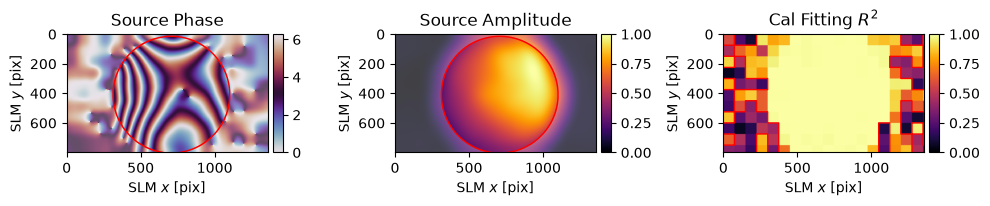

smooth: 100%|██████████| 16/16 [00:00<00:00, 26.45it/s]


In [15]:
calibration_ij = fs.calibrations["wavefront_superpixel"]["calibration_points"]

# Load the measured source amplitude (along with the correction of the first point),
# and fit the aperture to it.
fs.wavefront_calibration_superpixel_process(index=0, r2_threshold=.5, smooth=True)
slm.fit_aperture(edge_level=0.5)
slm.plot_source();

# Extract correction phase measured at every calibration point.
phases = slm.xp.stack([
    slm.xp.asarray(fs.wavefront_calibration_superpixel_process(
        index=i, r2_threshold=.5, smooth=True, remove_blaze=False, apply=False, remove_background=False)["phase"])
    for i in range(calibration_ij.shape[1])
])

`analysis.image_zernike_fit()` fits a whole stack of phase images at once. By default, it fits
the phase *gradient*, so wrapped phases need no unwrapping, and the fit is a single linear
least-squares solve against a Zernike basis which is rendered once and cached. When the SLM
is on the GPU, so is the fit.

In [16]:
import time
from slmsuite.holography.analysis import image_zernike_fit
from slmsuite.misc.xp import as_numpy
from slmsuite.holography.toolbox.phase import zernike_order_number

# Every term through radial order 6
fit_indices = list(range(1, zernike_order_number(6)))

# Warm up: renders and caches the basis
weights = as_numpy(image_zernike_fit(phases, slm, order=fit_indices))

start = time.perf_counter()
weights = as_numpy(image_zernike_fit(phases, slm, order=fit_indices))
duration = time.perf_counter() - start

print(f"Fit {phases.shape[0]} phase images ({slm.shape[1]} x {slm.shape[0]} pixels) "
      f"to {len(fit_indices)} Zernike terms in {1e3 * duration:.0f} ms.")

Fit 53 phase images (1358 x 800 pixels) to 27 Zernike terms in 18 ms.


To check the fit, we render each fitted Zernike sum with `zernike_sum()` and compare it with
the measured phase inside the aperture. The residual is wrapped and its piston removed, so
what remains is only the aberration that these terms cannot describe. Below, we show the best and worst fits
for comparison. The Zernike fit process can even resolve some discontinuities from the superpixel calibration method.

Residual RMS: median 0.35 rad, worst 0.82 rad


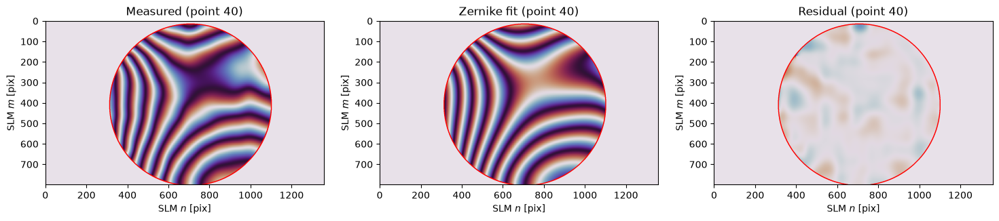

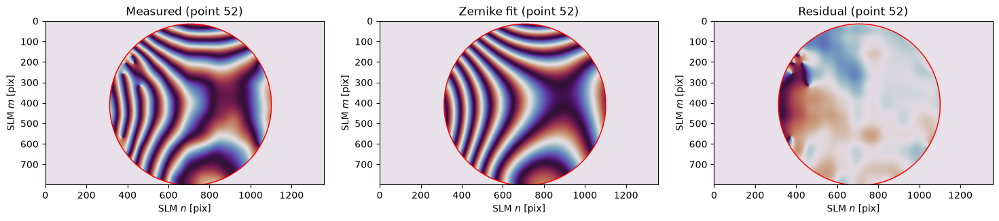

In [17]:
from slmsuite.holography.toolbox.phase import zernike_sum

# Compute sum using cp or np (depending on whether slm.xp is cupy or numpy)
xp = slm.xp
fitted = zernike_sum(slm, fit_indices, xp.asarray(weights))

# The wrapped residual inside the aperture, with the piston of each point removed.
mask = slm.aperture_mask
difference = xp.exp(1j * (phases - fitted))
difference *= xp.conj(xp.mean(difference[:, mask], axis=1))[:, None, None]
residual = xp.angle(difference)
rms = as_numpy(xp.sqrt(xp.mean(xp.square(residual[:, mask]), axis=1)))

print(f"Residual RMS: median {np.median(rms):.2f} rad, worst {np.max(rms):.2f} rad")

# The best/worst fits: measured, fitted, and residual phase.
for i in (int(np.argmin(rms)), int(np.argmax(rms))):
    fig, axs = plt.subplots(1, 3, figsize=(18, 4))
    for ax, image, title in zip(axs, (phases[i], fitted[i], residual[i]),
                                     ("Measured", "Zernike fit", "Residual")):
        plt.sca(ax)
        slm.plot(as_numpy(image * mask), title=f"{title} (point {i})", cbar=False)
    plt.show()

Finally, we pack the fits into a Zernike calibration: each point's tilts come from its
position on the camera, followed by the fitted terms. This has the same form as the
`calibrations["wavefront_zernike"]` which `.wavefront_calibrate_zernike()` produces,
so everything which follows can use it, including refining it with that calibration at the
end of this example. As the Zernike vectors now carry the whole correction, we also clear
the on-axis correction from `slm.source`.

In [18]:
# Add steering tilt to fitted tilt
corrected_spots = np.copy(weights)
corrected_spots[[1, 0]] += convert_vector(calibration_ij, from_units="ij", to_units="zernike", hardware=fs)

fs.calibrations["wavefront_zernike"] = {
    "zernike_indices": fit_indices,
    "calibration_points_ij": calibration_ij,
    "corrected_spots": corrected_spots,
    "spot_integration_width_ij": 51,
}
fs.save_calibration("wavefront_zernike")

# Keep a copy of the fit, which the Zernike calibration at the end starts from.
import copy
zernike_fit = copy.deepcopy(fs.calibrations["wavefront_zernike"])

# The Zernike vectors now carry the whole correction, so we clear the on-axis correction
# from the source. Holograms are then displayed exactly as computed.
slm.source["phase"] = slm.xp.zeros(slm.shape)

[INF] 21:02:12 FLIR Cam-PLM Saved 'wavefront_zernike' calibration to 'c:\Users\holodyne\Documents\GitHub\slmsuite-examples\examples\FLIR Cam-PLM-wavefront_zernike-calibration_00007.h5'.


#### Interpolated Aberration Correction

The calibration gives a corrected Zernike vector at each calibration point, but a hologram
should be able to target any point. Our anisoplanatism is strong enough that no single correction
works across the field of view, so each spot needs the correction local to its own position.

`.wavefront_calibrate_zernike_get()` interpolates the calibration to any point. It fits a
radial basis function through the calibrated vectors with an affine tail, so the tilt terms
$Z_2$ and $Z_1$ reproduce the refined map from camera position to blaze, and a spot still
lands where it was asked to. The higher order terms blend smoothly between calibration points.
Interpolation is only reliable within the calibrated region: outside of it, the aberration is
extrapolated linearly.

Now we lay out a large array: 30 by 30 spots spanning the SLM's entire field of view, minus
those near the zeroth order. The grid spans 90% of the field of view, so it
stays within the calibrated region. We interpolate the calibration at every spot.
The plot shows each Zernike coefficient across the field of view, with the calibration
points circled.

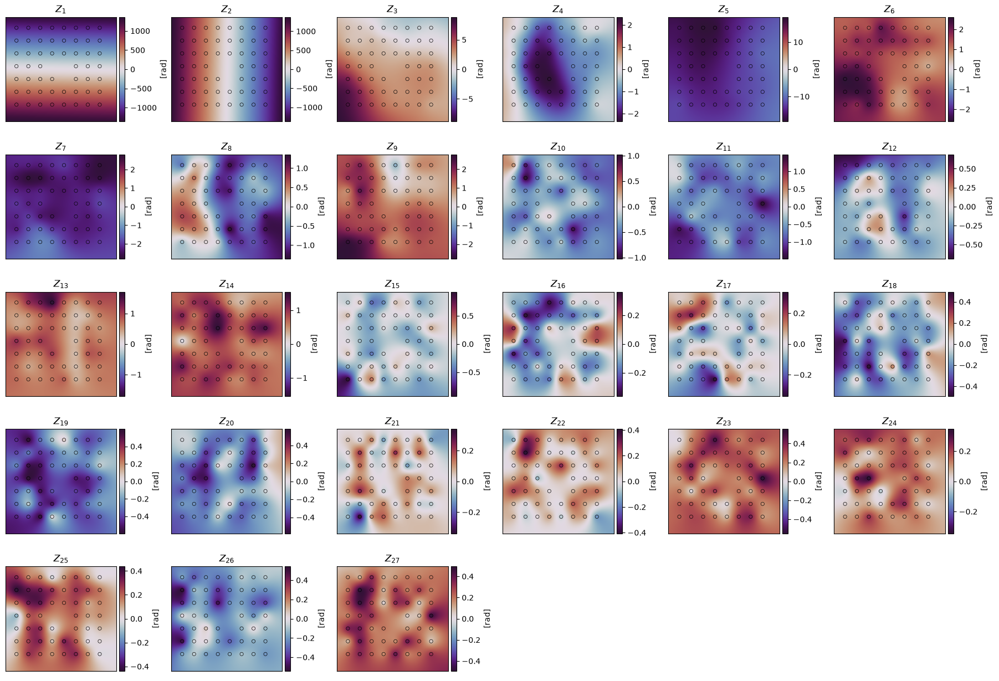

In [19]:
calibration = fs.calibrations["wavefront_zernike"]
zernike_indices = calibration["zernike_indices"]
calibration_ij = calibration["calibration_points_ij"]

# A large-scale array across the field of view, inside the calibrated region.
N = 30
targets_ij, targets_clear = field_grid_ij(N, fill=0.9)
spots_ij = targets_ij[:, targets_clear]

# The window about each spot, odd and no wider than the spot pitch.
pitch = np.min(np.ptp(targets_ij, axis=1)) / (N - 1)
width = int(min(pitch, calibration["spot_integration_width_ij"])) // 2 * 2 + 1

vectors_interpolated = fs.wavefront_calibrate_zernike_get(spots_ij, from_units="ij")
fs.wavefront_calibrate_zernike_get(plot=True);

To see what the interpolation buys us, we compare against the best *single* correction:
the average aberration over all of the calibration points, applied to every spot. Both sets
of vectors share the same tilt terms, so both holograms place their spots identically and
differ only in their higher order correction.

The interpolated vectors are exactly what `CompressedSpotHologram` expects for its
`spot_vectors`, using the calibrated `zernike_indices` as the basis. Each hologram is first
optimized computationally, then refined with experimental feedback from the camera
(`feedback="experimental_spot"`), which balances the measured power of the spots.

In [20]:
from slmsuite.holography.algorithms import CompressedSpotHologram

def project(hologram):
    slm.set_phase(hologram.get_phase(), settle=True)
    cam.flush()
    return cam.get_image()

def make_hologram(vectors):
    """A hologram of Zernike spots, optimized computationally and then with camera feedback."""
    hologram = CompressedSpotHologram(
        spot_vectors=vectors,
        basis=fit_indices,
        cameraslm=fs,
        cuda=True
    )
    hologram.spot_integration_width_ij = width
    hologram.optimize("WGS-Leonardo", maxiter=10, verbose=False)

    # Expose on the projected hologram, then refine it with experimental feedback.
    project(hologram)
    cam.autoexpose(set_fraction=0.5, verbose=False)
    hologram.optimize(
        "WGS-Nogrette",
        maxiter=10,
        feedback="experimental_spot",
        verbose=False
    )
    return hologram

# The average aberration of all the calibration points (every term but the x, y tilts).
aberration_global = np.mean(calibration["corrected_spots"][2:, :], axis=1, keepdims=True)

def global_vectors(vectors):
    result = np.copy(vectors)
    result[2:, :] = aberration_global
    return result

holograms = {
    "global": make_hologram(global_vectors(vectors_interpolated)),
    "interpolated": make_hologram(vectors_interpolated),
}

[INF] 21:02:13 CompressedSpotHologram #2 Initialized CompressedSpotHologram.
[INF] 21:02:18 CompressedSpotHologram #3 Initialized CompressedSpotHologram.


We project each hologram and measure the relative Strehl ratio of every spot
(`analysis.image_relative_strehl`: the fraction of a spot's power in its brightest pixel)
in a window about it. We also tile the windows to see all of the spots at once.

[INF] 21:02:24 FLIR Cam Autoexpose: 1.15e-02 s - 1996/4095


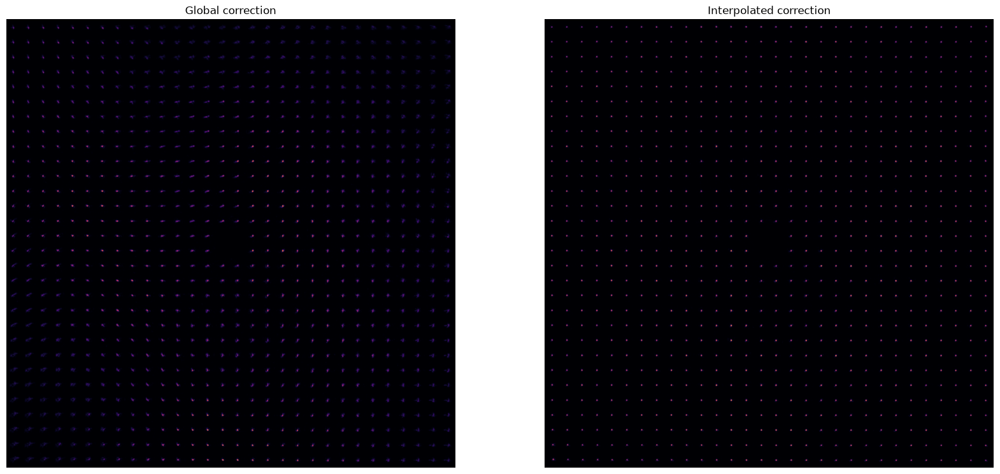

In [21]:
def spot_strehl(image, spots_ij):
    """The relative Strehl ratio of every spot in the image."""
    images = analysis.take(image, spots_ij, width, clip=True).astype(float)
    images[np.isnan(images)] = 0
    images = analysis.image_remove_field(images)
    return analysis.image_relative_strehl(images)

# Expose on the tighter (brighter) interpolated spots and share the exposure,
# so the two corrections are compared on equal footing.
project(holograms["interpolated"])
comparison_exposure_s = cam.autoexpose(set_fraction=1)

images = {}
strehl = {}
for label, hologram in holograms.items():
    images[label] = project(hologram)
    strehl[label] = spot_strehl(images[label], spots_ij)

fig, axs = plt.subplots(1, 2, figsize=(20, 10))
for ax, label in zip(axs, holograms):
    windows = analysis.take(images[label], targets_ij, width)
    windows[~targets_clear] = 0
    ax.imshow(analysis.take_tile(windows))
    ax.set_title(f"{label.capitalize()} correction")
    ax.axis("off")
plt.show()

With the global correction, only the spots near the middle of the field are sharp.
With the interpolated correction, every spot is. Mapping the relative Strehl ratio across the
field of view makes this quantitative:

      global: mean relative Strehl 0.363, worst 0.103
interpolated: mean relative Strehl 0.827, worst 0.693


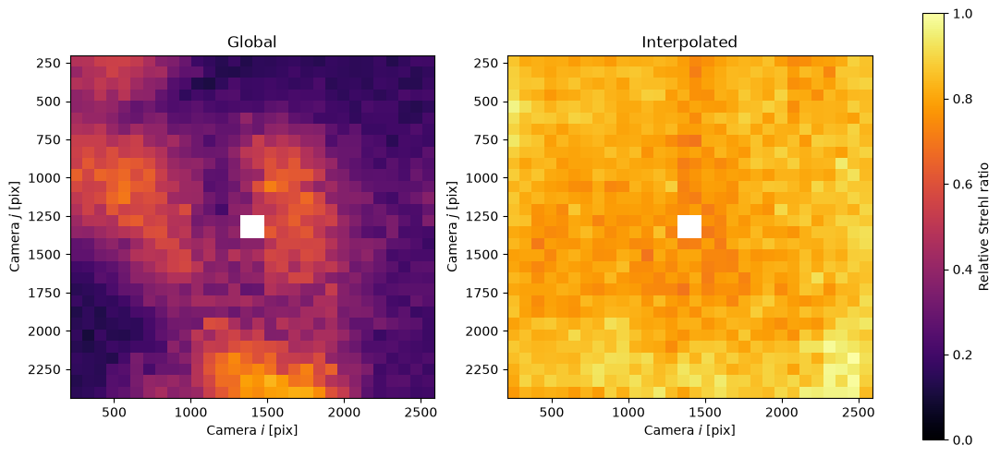

In [22]:
def plot_strehl_maps(labels):
    """Map the relative Strehl ratio of each hologram's spots across the field of view."""
    n = int(np.rint(np.sqrt(targets_ij.shape[1])))
    x = targets_ij[0].reshape(n, n)[0]
    y = targets_ij[1].reshape(n, n)[:, 0]
    (dx, dy) = (x[1] - x[0], y[1] - y[0])
    extent = (x[0] - dx/2, x[-1] + dx/2, y[-1] + dy/2, y[0] - dy/2)
    vmax = max(np.max(strehl[label]) for label in labels)

    fig, axs = plt.subplots(1, len(labels), figsize=(7 * len(labels), 6))
    for ax, label in zip(axs, labels):
        print(
            f"{label:>12}: mean relative Strehl {np.mean(strehl[label]):.3f}, "
            f"worst {np.min(strehl[label]):.3f}"
        )

        values = np.full(targets_ij.shape[1], np.nan)       # Excluded spots stay blank.
        values[targets_clear] = strehl[label]
        im = ax.imshow(values.reshape(n, n), extent=extent, vmin=0, vmax=vmax)
        ax.set_title(f"{label.capitalize()}")
        ax.set_xlabel("Camera $i$ [pix]")
        ax.set_ylabel("Camera $j$ [pix]")

    fig.colorbar(im, ax=axs, label="Relative Strehl ratio")
    plt.show()

# Normalize to best Strehl ("relative Strehl")
strehl_max = max(np.max(strehl[label]) for label in strehl.keys())
strehl = {label: strehl[label] / strehl_max for label in strehl.keys()}

plot_strehl_maps(["global", "interpolated"])

#### Dynamic Correction

Because interpolation is cheap, the correction follows the pattern wherever it moves. As in
the Zernike holography example, we steer a circle of spots around the field of view, but now
every spot carries the calibration interpolated at its current position. Each frame, the
hologram is warm-started from the previous one.

The spots are small compared with the field of view, so we downsample the camera image for the
.gifs and overexpose it so that the spots stand out. To see the shape of each spot, we also
inset a magnified view of the camera about its target position. The insets sit on a smaller
circle, toward the center, so that they don't cover the spots themselves.

In [23]:
import tqdm

# A circle of spots about the center of the field of view, most of the way to its edge.
N = 24
box_ij = fs.get_farfield_extent(inscribe=True)
center = np.mean(box_ij[:, :4], axis=1, keepdims=True)
radius = 0.4 * np.min(np.ptp(box_ij, axis=1))

def get_circle(theta=0):
    angles = np.linspace(0, 2*np.pi, N, endpoint=False) + theta
    return center + radius * np.vstack((np.cos(angles), np.sin(angles)))

def get_vectors(circle_ij):
    vectors = fs.wavefront_calibrate_zernike_get(circle_ij, from_units="ij")
    return {"global": global_vectors(vectors), "interpolated": vectors}

# The camera region around the circle, downsampled for the .gifs.
step = 4
(x0, y0) = (center.ravel() - radius - 50).astype(int)
(x1, y1) = (center.ravel() + radius + 50).astype(int)

# The insets sit at 85% of the radius, and are as large as fits there without overlapping.
zoom = 2                                                        # .gif pixels per camera pixel
inset_radius = 0.85 * radius
inset_width = int(2 * inset_radius * np.sin(np.pi / N) / (step * zoom)) - 1   # Camera pixels
inset_size = zoom * inset_width                                 # .gif pixels
distance = np.hypot(*np.mgrid[:inset_size, :inset_size] - (inset_size - 1) / 2)
disk = distance < inset_size / 2 - 1
rim = ~disk & (distance < inset_size / 2)

def get_frame(image, circle_ij):
    """Downsample the image about the circle, and inset a magnified view of every spot."""
    frame = image[y0:y1:step, x0:x1:step].astype(float)
    insets = analysis.take(image, circle_ij, inset_width)
    insets = insets.repeat(zoom, axis=1).repeat(zoom, axis=2)

    # Each inset lies on the line from the center of the circle to its spot.
    inset_ij = center + (inset_radius / radius) * (circle_ij - center)
    inset_xy = np.rint((inset_ij - [[x0], [y0]]) / step - inset_size / 2).astype(int)
    for (x, y), inset in zip(inset_xy.T, insets):
        region = frame[y:y+inset_size, x:x+inset_size]
        region[disk] = inset[disk]
        region[rim] = cam.bitresolution / 2                     # Outline each inset.
    return frame

circle = {
    label: CompressedSpotHologram(spot_vectors=v, basis=zernike_indices, cameraslm=fs, cuda=True)
    for label, v in get_vectors(get_circle()).items()
}
for hologram in circle.values():
    hologram.optimize("WGS-Leonardo", maxiter=50, verbose=False)

project(circle["interpolated"])
cam.autoexpose(set_fraction=1)

# Rotate by one spot spacing, so the .gifs loop seamlessly.
frames = {label: [] for label in circle}
for x in tqdm.tqdm(np.linspace(0, 2*np.pi / N, 25, endpoint=False)):
    circle_ij = get_circle(x)
    for label, v in get_vectors(circle_ij).items():
        circle[label].spot_zernike = v
        circle[label].optimize("WGS-Leonardo", maxiter=20, verbose=False)
        frames[label].append(get_frame(project(circle[label]), circle_ij))

[INF] 21:02:26 CompressedSpotHologram #4 Initialized CompressedSpotHologram.
[INF] 21:02:26 CompressedSpotHologram #5 Initialized CompressedSpotHologram.
[INF] 21:02:28 FLIR Cam Autoexpose: 3.69e-04 s - 1993/4095


100%|██████████| 25/25 [00:17<00:00,  1.46it/s]


Let's save the data:

In [24]:
from slmsuite.holography.analysis.files import save_image

for label, f in frames.items():
    save_image(f"ex-multipoint-{label}.gif", f, cmap="Blues", border=127, normalize=True, loop=0)
    save_image(f"ex-multipoint-{label}-dark.gif", f, cmap="inferno", border=127, normalize=True, loop=0)

<!-- ![global](ex-multipoint-global.gif) ![interpolated](ex-multipoint-interpolated.gif) -->
![global](ex-multipoint-global-dark.gif) ![interpolated](ex-multipoint-interpolated-dark.gif)

The insets make the difference plain: the spots with the global correction smear away from the
center of the field, while the interpolated correction keeps spots tight across the SLM's entire
field of view.
Multipoint calibration together with interpolation thus gives aberration-corrected
holograms with any number of spots at arbitrary positions, not only at the points where
we calibrated.

#### Zernike Wavefront Calibration

Our Zernike vectors come from the superpixel measurement rather than from the spots
themselves, so they inherit its errors: the smoothing of the measured phase, the terms that the
fit leaves out, and the Fourier calibration's placement of each spot. We can refine them on
the spots directly.

`.wavefront_calibrate_zernike()` sweeps the addition of each Zernike term to a spot array,
fitting to find the perturbation that realizes tight spots according to a figure of merit
(defaults to spot area `analysis.image_areas`). Then the calibration subtracts the perturbation
from the coordinate of each spot in Zernike-space. Passing `calibration_points=None` starts from
the calibration stored in `calibrations["wavefront_zernike"]`. Each call stores its refined
result there, so we first restore our fit, which starts the refinement from the fit even
when this section is run again.

We can test the Zernike wavefront calibration settings without starting an optimization
step by using `perturbation=0`. Note that we also use the `plot=2` flag to plot zoomed
in windows on our array of spots.

Like superpixel calibration, the Zernike calibration keeps the camera's exposure fixed. We
first project the array and autoexpose it below saturation, since the spots will brighten as
they are corrected. After each round of optimization, the calibration leaves its corrected
array on the SLM, so we re-expose on it.

[INF] 21:02:46 CompressedSpotHologram #6 Initialized CompressedSpotHologram.


[INF] 21:02:47 FLIR Cam Autoexpose: 5.53e-04 s - 1982/4095
[WRN] 21:02:47 FLIR Cam Attempted to set exposure to 0.0002765 seconds, but realized 0.000265 seconds.
[INF] 21:02:47 CompressedSpotHologram #7 Initialized CompressedSpotHologram.


optimize_weights: 100%|██████████| 10/10 [00:03<00:00,  3.09it/s]


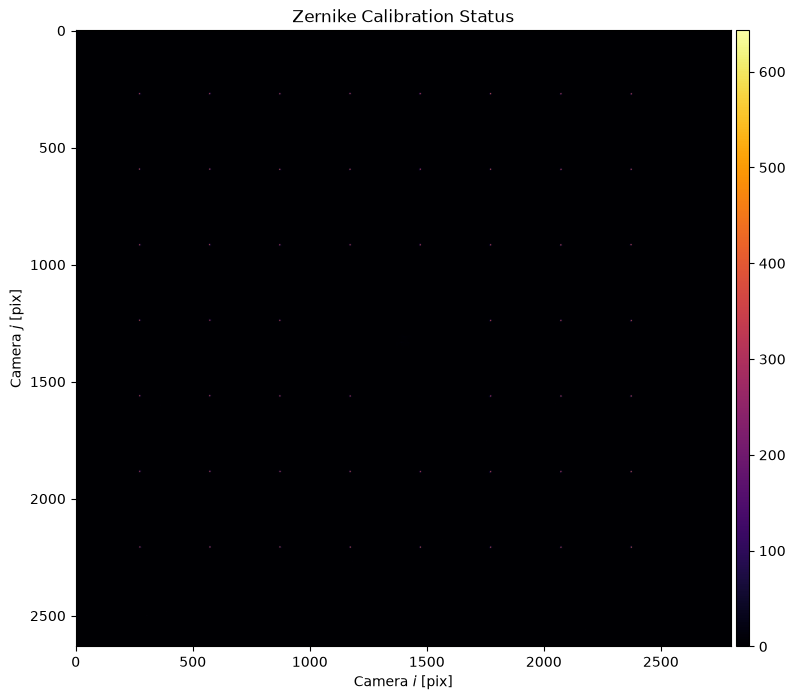

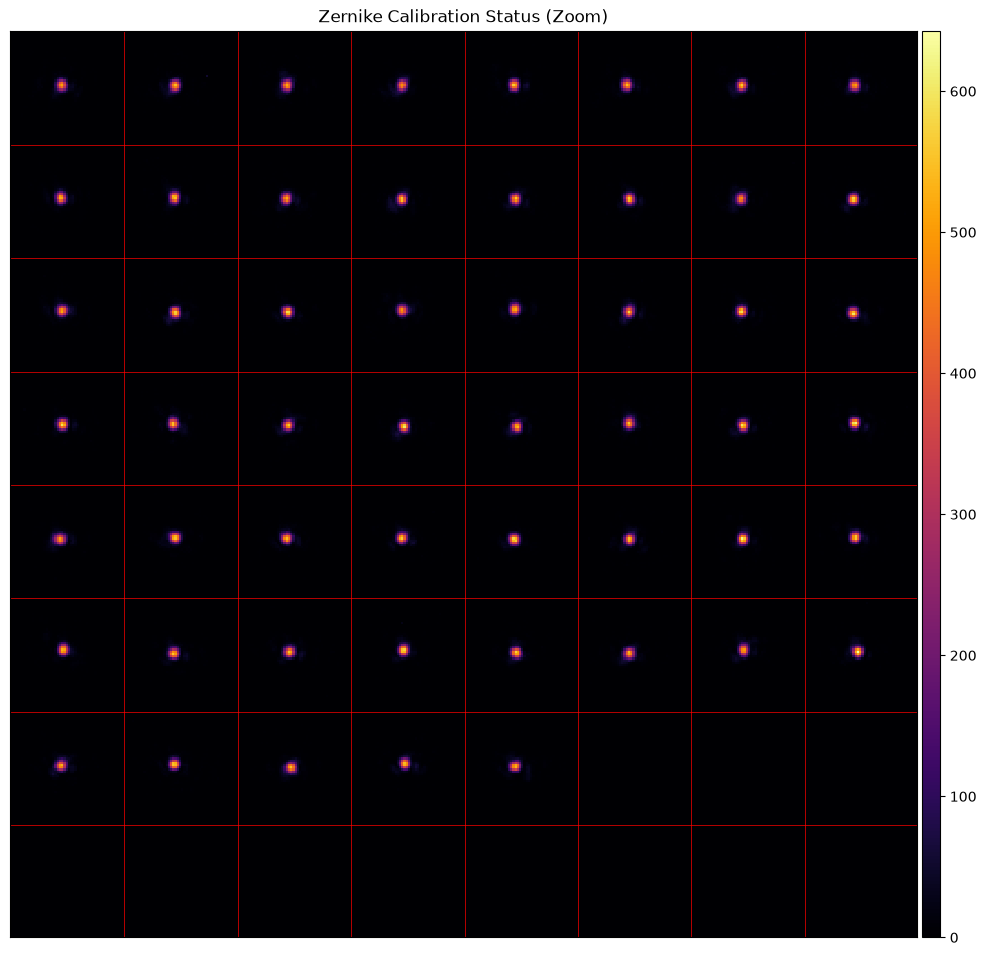

In [25]:
# Start from the Zernike fit.
fs.calibrations["wavefront_zernike"] = copy.deepcopy(zernike_fit)

# Project the array and expose on it.
fs.wavefront_calibrate_zernike(None, perturbation=0, optimize_weights=False)
cam.autoexpose(set_fraction=0.25)

fs.wavefront_calibrate_zernike(None, perturbation=0, plot=2);

Our fit already corrects each spot for the aberration local to it. What remains is a small
residual, much of it shared by every spot: errors from the superpixel measurement and from the
fit itself. We change two defaults to measure this residual reliably:

- `global_correction=True` averages the fitted correction over all of the spots and adds it
  to every spot's vector. Each spot keeps its own interpolated correction, and the shared residual
  is measured by all of the spots at once, which averages away the noise of any single spot.
- The default figure of merit, spot area, first zeros every pixel in a spot's window below a
  threshold (`analysis.image_remove_field()`). A small high-order aberration mostly moves
  light out of the spot into a faint halo, which this threshold removes. The metric then barely
  changes near the optimum, and the noise decides each fit. Instead, we pass a `callback=`
  which only subtracts the background, and measures the sharpness $\sum I^2$ of each spot. The
  sharpness falls as soon as light leaves the core of the spot. The calibration minimizes its
  figure of merit, so we return the negative.

We first sweep each term over $\pm\pi$ to find the larger corrections, then over $\pm 1$ rad to
refine them.

In [26]:
def spot_sharpness():
    """Negative sharpness of each calibration spot (lower is better), keeping the faint halo."""
    calibration_ij = fs.calibrations["wavefront_zernike"]["calibration_points_ij"]
    windows = analysis.take(cam.get_image(), calibration_ij, 51, clip=True).astype(float)
    windows[np.isnan(windows)] = 0
    windows -= np.median(windows, axis=(1, 2), keepdims=True)  # Remove the background only.
    windows /= np.mean(np.sum(windows, axis=(1, 2)))           # Normalize out laser power.
    return -np.sum(np.square(windows), axis=(1, 2))

for perturbation in (np.pi, 1):
    fs.wavefront_calibrate_zernike(
        None,
        zernike_indices=zernike_indices,
        perturbation=perturbation,
        global_correction=True,
        callback=spot_sharpness,
        plot=False
    )
    cam.autoexpose(set_fraction=0.25)       # Re-expose on the corrected array.

[INF] 21:02:52 CompressedSpotHologram #8 Initialized CompressedSpotHologram.


optimize_weights: 100%|██████████| 10/10 [00:03<00:00,  3.04it/s]


[INF] 21:02:56 CompressedSpotHologram #8 Refine offset: avergage shift 0.000129 kxy distance.


[INF] 21:03:45 FLIR Cam Autoexpose: 7.10e-04 s - 2032/4095
[WRN] 21:03:45 FLIR Cam Attempted to set exposure to 0.000355 seconds, but realized 0.000343 seconds.
[INF] 21:03:45 CompressedSpotHologram #9 Initialized CompressedSpotHologram.


optimize_weights: 100%|██████████| 10/10 [00:03<00:00,  3.10it/s]


[INF] 21:03:49 CompressedSpotHologram #9 Refine offset: avergage shift 0.000066 kxy distance.


[WRN] 21:03:51 FLIR Cam-PLM Zernike Z_3: 2% of fitted optima hit the perturbation edge; consider widening `perturbation`.


[WRN] 21:03:55 FLIR Cam-PLM Zernike Z_5: 4% of fitted optima hit the perturbation edge; consider widening `perturbation`.


[INF] 21:04:38 FLIR Cam Autoexpose: 7.10e-04 s - 2063/4095
[WRN] 21:04:38 FLIR Cam Attempted to set exposure to 0.000355 seconds, but realized 0.000343 seconds.


Plot the results, including a look at how some of the Zernike coefficients shifted:

[INF] 21:04:38 CompressedSpotHologram #10 Initialized CompressedSpotHologram.


optimize_weights: 100%|██████████| 10/10 [00:03<00:00,  3.06it/s]


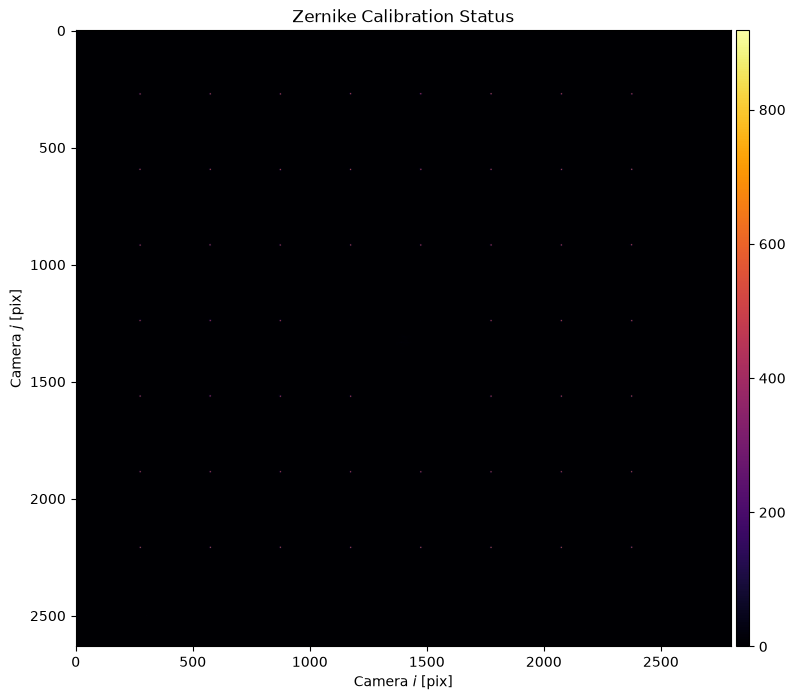

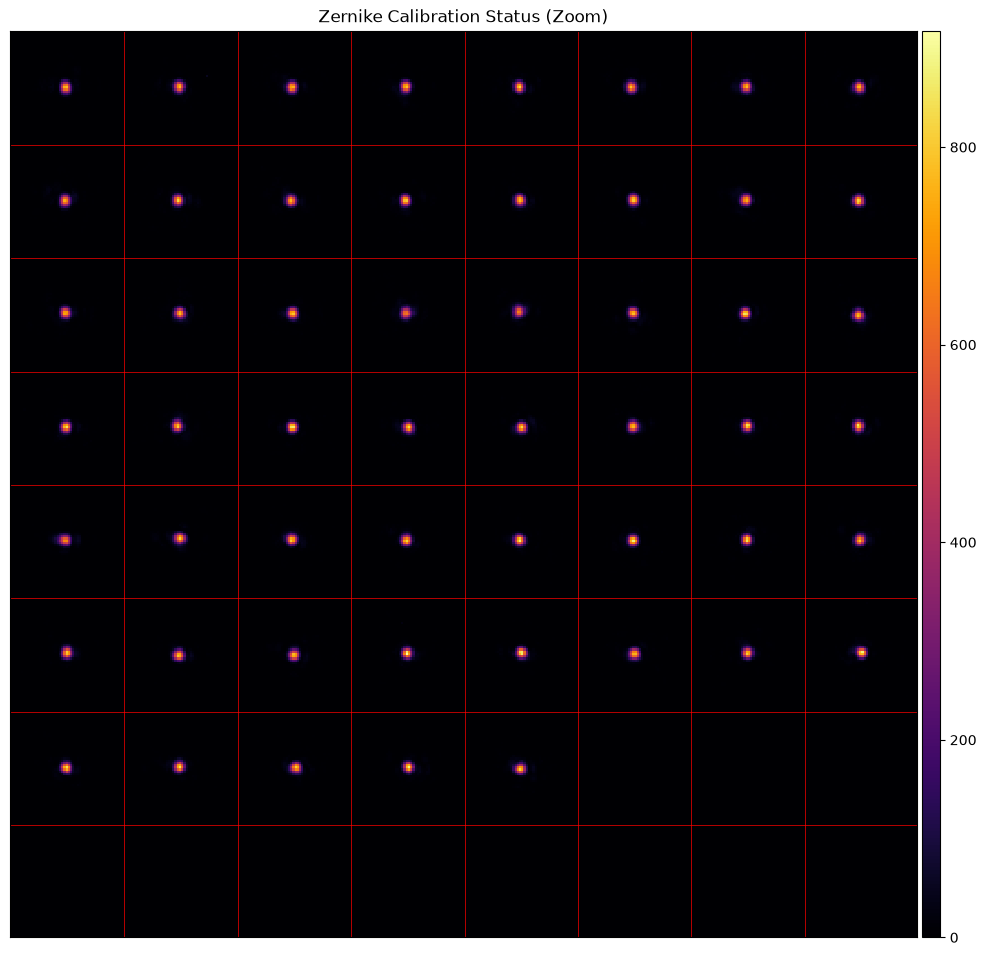

In [27]:
fs.wavefront_calibrate_zernike(None, perturbation=0, plot=2);

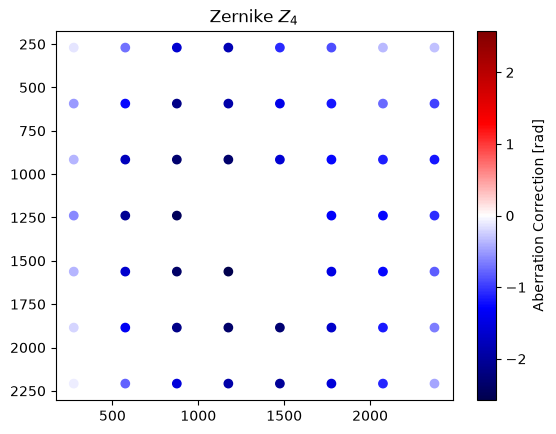

In [28]:
fs._wavefront_calibrate_zernike_plot_raw(index=3)

This method is quite general. Above, we used `callback=` to change how the camera judges
the spots. `.wavefront_calibrate_zernike()` also accepts a `metric=`, which judges the
spot images taken by the default callback.

- The `metric()` takes in a stack of spot images, each image corresponding to
  one spot, and is expected to return a list of the goodness of each image.
- `callback()` overrides camera functionality and the user can choose how to
  determine the goodness. This, for instance, could be a measure of trap depth
  on atoms or similar measurement that avoids aberration between the camera and
  an experimental plane. After all, perfect spots on the camera might correspond
  to very distorted spots in an experimental plane.

The refined calibration drops straight into the interpolation from before. We project the same
large scale array with the refined calibration, at the same exposure, and compare it with the
interpolated fit:

[INF] 21:04:43 CompressedSpotHologram #11 Initialized CompressedSpotHologram.


interpolated: mean relative Strehl 0.827, worst 0.693
     refined: mean relative Strehl 0.863, worst 0.707


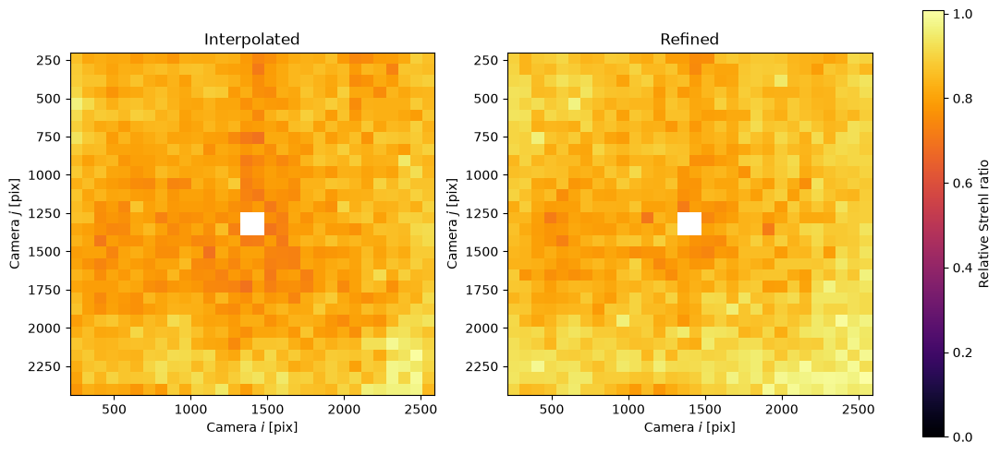

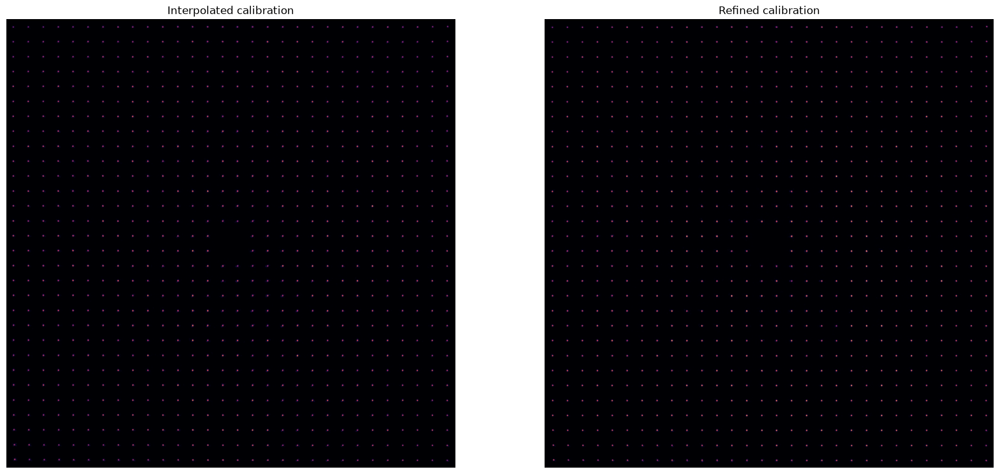

In [29]:
holograms["refined"] = make_hologram(fs.wavefront_calibrate_zernike_get(spots_ij, from_units="ij"))

cam.set_exposure(comparison_exposure_s)
images["refined"] = project(holograms["refined"])
strehl["refined"] = spot_strehl(images["refined"], spots_ij) / strehl_max    # Same scale as before.

plot_strehl_maps(["interpolated", "refined"])

fig, axs = plt.subplots(1, 2, figsize=(20, 10))
for ax, label in zip(axs, ["interpolated", "refined"]):
    windows = analysis.take(images[label], targets_ij, width)
    windows[~targets_clear] = 0
    ax.imshow(analysis.take_tile(windows))
    ax.set_title(f"{label.capitalize()} calibration")
    ax.axis("off")
plt.show()

Moreover, the anisoplanatic aberration problem is exacerbated for high-NA setups
where light is bent to a much larger degree than our simple <.1 NA setup does. As
field of view sizes are pushed larger and larger, our **software solution** to compensating
for aberration becomes increasingly important to close the gap between imperfect aberration mitigation
engineered into the optical train and the ideal of aberration-free imaging.

In [30]:
slm.close()
cam.close()